# Hertfordshire-Secondary-School-Performance-Analysis

This notebook builds a four-year KS4 analysis panel for Hertfordshire schools using data published by the government (https://www.gov.uk/school-performance-tables).

Scope:
- Academic years: `2021-2022`, `2022-2023`, `2023-2024`, `2024-2025`
- Outcomes: Progress 8, Attainment 8, and English/maths grade 5+ measures
- Context: deprivation, attendance, SEND, school type, admissions policy, roll size, and gender

In [55]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
YEARS = ["2021-2022", "2022-2023", "2023-2024", "2024-2025"]


## Raw File Exploration

Before defining the analysis columns and filters, inspect the raw yearly files to see available columns, row counts, valid school rows, and census `SCHOOLTYPE` groups.

In [56]:
RAW_FILES = {
    "ks4": "919_ks4final.csv",
    "census": "919_census.csv",
    "absence": "919_abs.csv",
}
CANDIDATE_ANALYSIS_COLUMNS = [
    "P8MEA", "P8MEAENG", "P8MEAMAT", "P8MEAEBAC", "P8MEAOPEN",
    "ATT8SCR", "ATT8SCRENG", "ATT8SCRMAT", "ATT8SCREBAC", "ATT8SCROPEN",
    "PTL2BASICS_95", "PNUMFSMEVER", "PERCTOT", "PPERSABS10",
    "PSEN_ALL4", "SCHOOLTYPE", "ADMPOL", "NOR", "NORG", "NORB",
    "PNORG", "PNORB", "EGENDER",
]

raw_file_rows = []
raw_column_rows = []
raw_schooltype_rows = []

for year in YEARS:
    year_dir = DATA_DIR / year
    for source_name in RAW_FILES:
        file_name = RAW_FILES[source_name]
        path = year_dir / file_name
        if not path.exists():
            raw_file_rows.append({"academic_year": year, "file": file_name, "exists": False, "rows": 0, "columns": 0, "valid_urn_rows": pd.NA})
            continue

        data = pd.read_csv(path, dtype="string", low_memory=False)
        urn = pd.to_numeric(data["URN"], errors="coerce") if "URN" in data.columns else pd.Series(pd.NA, index=data.index)
        raw_file_rows.append(
            {
                "academic_year": year,
                "file": file_name,
                "exists": True,
                "rows": len(data),
                "columns": len(data.columns),
                "valid_urn_rows": int(urn.notna().sum()),
            }
        )

        for column in CANDIDATE_ANALYSIS_COLUMNS:
            if column in data.columns:
                raw_column_rows.append({"academic_year": year, "file": file_name, "column": column})

    census_path = year_dir / RAW_FILES["census"]
    if census_path.exists():
        census = pd.read_csv(census_path, dtype="string", low_memory=False)
        census["URN_NUM"] = pd.to_numeric(census["URN"], errors="coerce")
        census = census[census["URN_NUM"].notna()].drop_duplicates(subset="URN_NUM")
        for schooltype, count in census["SCHOOLTYPE"].fillna("<missing>").value_counts(dropna=False).items():
            raw_schooltype_rows.append({"academic_year": year, "SCHOOLTYPE": schooltype, "census_rows": int(count)})

raw_file_summary = pd.DataFrame(raw_file_rows)
raw_column_presence = (
    pd.DataFrame(raw_column_rows)
    .assign(present=True)
    .pivot_table(index=["column", "file"], columns="academic_year", values="present", aggfunc="any", fill_value=False)
    .reset_index()
)
raw_schooltype_counts = pd.DataFrame(raw_schooltype_rows).sort_values(["academic_year", "census_rows"], ascending=[True, False])
raw_schooltype_group_counts = raw_schooltype_counts.groupby("academic_year").size().rename("census_schooltype_groups")

display(raw_file_summary)
display(raw_column_presence)
display(raw_schooltype_group_counts)
display(raw_schooltype_counts)


,academic_year,file,exists,rows,columns,valid_urn_rows
0,2021-2022,919_ks4final.csv,True,132,514,129
1,2021-2022,919_census.csv,True,591,23,585
2,2021-2022,919_abs.csv,True,517,5,511
3,2022-2023,919_ks4final.csv,True,133,515,130
4,2022-2023,919_census.csv,True,591,23,585
5,2022-2023,919_abs.csv,True,517,5,511
6,2023-2024,919_ks4final.csv,True,133,429,130
7,2023-2024,919_census.csv,True,594,23,588
8,2023-2024,919_abs.csv,True,518,5,512
9,2024-2025,919_ks4final.csv,True,132,497,129


academic_year,column,file,2021-2022,2022-2023,2023-2024,2024-2025
0,ADMPOL,919_ks4final.csv,True,True,True,True
1,ATT8SCR,919_ks4final.csv,True,True,True,True
2,ATT8SCREBAC,919_ks4final.csv,True,True,True,True
3,ATT8SCRENG,919_ks4final.csv,True,True,True,True
4,ATT8SCRMAT,919_ks4final.csv,True,True,True,True
5,ATT8SCROPEN,919_ks4final.csv,True,True,True,True
6,EGENDER,919_ks4final.csv,True,True,True,True
7,NOR,919_census.csv,True,True,True,True
8,NORB,919_census.csv,True,True,True,True
9,NORG,919_census.csv,True,True,True,True


academic_year
2021-2022    7
2022-2023    7
2023-2024    7
2024-2025    7
Name: census_schooltype_groups, dtype: int64

,academic_year,SCHOOLTYPE,census_rows
0,2021-2022,State-funded primary,403
1,2021-2022,State-funded secondary,82
2,2021-2022,Independent school,52
3,2021-2022,State-funded special school,25
4,2021-2022,State-funded nursery,14
5,2021-2022,Pupil referral unit,8
6,2021-2022,Non-maintained special school,1
7,2022-2023,State-funded primary,402
8,2022-2023,State-funded secondary,83
9,2022-2023,Independent school,52


## Analysis Definitions

Based on the raw file exploration, define the final school-type filter, selected columns, and cleaning codes used by the loader.

In [57]:
ALLOWED_SCHOOLTYPES = ["State-funded secondary"]
EXPECTED_KS4_ROWS = {}

OUTCOME_COLUMNS = [
    "P8MEA",
    "P8MEAENG",
    "P8MEAMAT",
    "P8MEAEBAC",
    "P8MEAOPEN",
    "ATT8SCR",
    "ATT8SCRENG",
    "ATT8SCRMAT",
    "ATT8SCREBAC",
    "ATT8SCROPEN",
    "PTL2BASICS_95",
]

CONTEXT_COLUMNS = [
    "PNUMFSMEVER",
    "PERCTOT",
    "PPERSABS10",
    "PSEN_ALL4",
    "SCHOOLTYPE",
    "ADMPOL",
    "NOR",
    "NORG",
    "NORB",
    "PNORG",
    "PNORB",
    "EGENDER",
]

IDENTIFIER_COLUMNS = ["academic_year", "URN", "SCHNAME"]
ANALYSIS_COLUMNS = IDENTIFIER_COLUMNS + OUTCOME_COLUMNS + CONTEXT_COLUMNS
NUMERIC_COLUMNS = OUTCOME_COLUMNS + ["PNUMFSMEVER", "PERCTOT", "PPERSABS10", "PSEN_ALL4", "NOR", "NORG", "NORB", "PNORG", "PNORB"]

MISSING_CODES = {
    "",
    "-",
    "NA",
    "N/A",
    "NAN",
    "NE",
    "NEW",
    "NP",
    "SUPP",
    "LOWCOV",
    "SP",
    "X",
}


In [58]:
def clean_numeric(series: pd.Series) -> pd.Series:
    """Convert school performance strings, percentages, and suppression codes to numeric values."""
    text = series.astype("string").str.strip()
    text = text.str.replace(",", "", regex=False).str.replace("%", "", regex=False)
    text = text.mask(text.str.upper().isin(MISSING_CODES))
    return pd.to_numeric(text, errors="coerce")


def normalise_urn(series: pd.Series) -> pd.Series:
    """Normalise URNs that sometimes arrive as strings like '117600.0'."""
    return pd.to_numeric(series, errors="coerce").astype("Int64")


def read_selected_csv(path: Path, columns: list[str]) -> pd.DataFrame:
    """Read only requested columns and add missing requested columns as NA."""
    header = pd.read_csv(path, nrows=0).columns.tolist()
    present = [column for column in columns if column in header]
    data = pd.read_csv(path, usecols=present, dtype="string", low_memory=False)
    for column in columns:
        if column not in data.columns:
            data[column] = pd.NA
    return data[columns]


def load_year(year: str) -> pd.DataFrame:
    year_dir = DATA_DIR / year
    ks4_path = year_dir / RAW_FILES["ks4"]
    census_path = year_dir / RAW_FILES["census"]
    absence_path = year_dir / RAW_FILES["absence"]

    ks4_columns = ["URN", "SCHNAME", "EGENDER", "ADMPOL", "PSEN_ALL4"] + OUTCOME_COLUMNS
    census_columns = ["URN", "SCHOOLTYPE", "NOR", "NORG", "NORB", "PNORG", "PNORB", "PNUMFSMEVER"]
    absence_columns = ["URN", "PERCTOT", "PPERSABS10"]

    ks4 = read_selected_csv(ks4_path, ks4_columns)
    ks4["academic_year"] = year
    ks4["URN"] = normalise_urn(ks4["URN"])
    ks4 = ks4[ks4["URN"].notna()].copy()
    census = read_selected_csv(census_path, census_columns)
    census["URN"] = normalise_urn(census["URN"])
    census = census[census["URN"].notna()].drop_duplicates(subset="URN")

    panel = ks4.merge(census, on="URN", how="left", validate="many_to_one")
    # Keep only the school types selected for this analysis before building the panel.
    panel = panel[panel["SCHOOLTYPE"].isin(ALLOWED_SCHOOLTYPES)].copy()

    if absence_path.exists():
        absence = read_selected_csv(absence_path, absence_columns)
        absence["URN"] = normalise_urn(absence["URN"])
        absence = absence[absence["URN"].notna()].drop_duplicates(subset="URN")
        panel = panel.merge(absence, on="URN", how="left", validate="many_to_one")
    else:
        panel["PERCTOT"] = pd.NA
        panel["PPERSABS10"] = pd.NA

    for column in NUMERIC_COLUMNS:
        panel[column] = clean_numeric(panel[column])

    return panel[ANALYSIS_COLUMNS]


def build_panel(years: list[str] = YEARS) -> pd.DataFrame:
    return pd.concat([load_year(year) for year in years], ignore_index=True)

## Preliminary Source Audit

This section derives the row-count checks, inspects the census `SCHOOLTYPE` groups, and identifies which groups are retained for the analysis panel.

In [59]:
audit_rows = []
schooltype_rows = []
column_availability_rows = []

source_columns = {
    "ks4": ["URN", "SCHNAME", "EGENDER", "ADMPOL", "PSEN_ALL4"] + OUTCOME_COLUMNS,
    "census": ["URN", "SCHOOLTYPE", "NOR", "NORG", "NORB", "PNORG", "PNORB", "PNUMFSMEVER"],
    "absence": ["URN", "PERCTOT", "PPERSABS10"],
}

for year in YEARS:
    year_dir = DATA_DIR / year
    source_paths = {source_name: year_dir / file_name for source_name, file_name in RAW_FILES.items()}
    ks4_path = source_paths["ks4"]
    census_path = source_paths["census"]
    absence_path = source_paths["absence"]

    ks4_raw = pd.read_csv(ks4_path, dtype="string", low_memory=False)
    ks4_urn = normalise_urn(ks4_raw["URN"])
    valid_ks4 = ks4_raw.assign(URN_NUM=ks4_urn).loc[ks4_urn.notna()].copy()

    audit_rows.append(
        {
            "academic_year": year,
            "raw_ks4_rows": len(ks4_raw),
            "valid_urn_rows": int(ks4_urn.notna().sum()),
            "invalid_urn_rows": int(ks4_urn.isna().sum()),
            "unique_school_urns": int(ks4_urn.dropna().nunique()),
        }
    )

    census_raw = pd.read_csv(census_path, dtype="string", low_memory=False)
    census = census_raw.assign(URN_NUM=normalise_urn(census_raw["URN"]))
    census = census[census["URN_NUM"].notna()].drop_duplicates(subset="URN_NUM")
    schooltype_join = valid_ks4[["URN_NUM"]].merge(
        census[["URN_NUM", "SCHOOLTYPE"]], on="URN_NUM", how="left", validate="many_to_one"
    )
    audit_rows[-1]["retained_schooltype_rows"] = int(schooltype_join["SCHOOLTYPE"].isin(ALLOWED_SCHOOLTYPES).sum())
    schooltype_counts = schooltype_join["SCHOOLTYPE"].fillna("<missing>").value_counts(dropna=False)
    for schooltype, count in schooltype_counts.items():
        schooltype_rows.append(
            {
                "academic_year": year,
                "SCHOOLTYPE": schooltype,
                "schools": int(count),
                "kept_in_analysis": schooltype in ALLOWED_SCHOOLTYPES,
                "share_pct": round(count / len(valid_ks4) * 100, 1),
            }
        )

    for source_name, expected_columns in source_columns.items():
        path = source_paths[source_name]
        if path.exists():
            columns = set(pd.read_csv(path, nrows=0).columns)
            missing = [column for column in expected_columns if column not in columns]
            present = len(expected_columns) - len(missing)
        else:
            missing = expected_columns
            present = 0
        column_availability_rows.append(
            {
                "academic_year": year,
                "source": source_name,
                "expected_columns": len(expected_columns),
                "present_columns": present,
                "missing_columns": ", ".join(missing) if missing else "",
            }
        )

source_audit = pd.DataFrame(audit_rows)
schooltype_counts = pd.DataFrame(schooltype_rows).sort_values(["academic_year", "schools"], ascending=[True, False])
schooltype_group_counts = schooltype_counts.groupby("academic_year").size().rename("all_discovered_schooltype_groups")
retained_schooltype_counts = schooltype_counts[schooltype_counts["kept_in_analysis"]].copy()
retained_schooltype_group_counts = retained_schooltype_counts.groupby("academic_year").size().rename("retained_schooltype_groups")
column_availability = pd.DataFrame(column_availability_rows)
EXPECTED_KS4_ROWS = source_audit.set_index("academic_year")["retained_schooltype_rows"].to_dict()

display(source_audit)
display(column_availability)
display(schooltype_group_counts)
display(retained_schooltype_group_counts)
display(retained_schooltype_counts)

,academic_year,raw_ks4_rows,valid_urn_rows,invalid_urn_rows,unique_school_urns,retained_schooltype_rows
0,2021-2022,132,129,3,129,80
1,2022-2023,133,130,3,130,81
2,2023-2024,133,130,3,130,79
3,2024-2025,132,129,3,129,80


,academic_year,source,expected_columns,present_columns,missing_columns
0,2021-2022,ks4,16,16,
1,2021-2022,census,8,8,
2,2021-2022,absence,3,3,
3,2022-2023,ks4,16,16,
4,2022-2023,census,8,8,
5,2022-2023,absence,3,3,
6,2023-2024,ks4,16,16,
7,2023-2024,census,8,8,
8,2023-2024,absence,3,3,
9,2024-2025,ks4,16,16,


academic_year
2021-2022    5
2022-2023    5
2023-2024    5
2024-2025    4
Name: all_discovered_schooltype_groups, dtype: int64

academic_year
2021-2022    1
2022-2023    1
2023-2024    1
2024-2025    1
Name: retained_schooltype_groups, dtype: int64

,academic_year,SCHOOLTYPE,schools,kept_in_analysis,share_pct
0,2021-2022,State-funded secondary,80,True,62.00
5,2022-2023,State-funded secondary,81,True,62.30
10,2023-2024,State-funded secondary,79,True,60.80
15,2024-2025,State-funded secondary,80,True,62.00


In [60]:
panel = build_panel()

display(panel.head())
display(panel.tail())
print(f"Rows: {len(panel):,}")
print(f"Columns: {len(panel.columns):,}")

,academic_year,URN,SCHNAME,P8MEA,P8MEAENG,P8MEAMAT,P8MEAEBAC,P8MEAOPEN,ATT8SCR,ATT8SCRENG,ATT8SCRMAT,ATT8SCREBAC,ATT8SCROPEN,PTL2BASICS_95,PNUMFSMEVER,PERCTOT,PPERSABS10,PSEN_ALL4,SCHOOLTYPE,ADMPOL,NOR,NORG,NORB,PNORG,PNORB,EGENDER
0,2021-2022,145430,The Adeyfield Academy,-0.67,-0.56,-0.46,-1.32,-0.29,34.90,8.00,6.90,8.00,11.90,21.00,40.34,11.10,36.60,25.00,State-funded secondary,NSE,642,305,337,47.51,52.49,MIXED
1,2021-2022,117578,Ashlyns School,0.16,0.20,0.05,0.09,0.24,54.50,11.70,10.40,15.70,16.70,61.00,12.30,8.70,25.10,17.00,State-funded secondary,NSE,1484,730,754,49.19,50.81,MIXED
2,2021-2022,117552,The Astley Cooper School,-0.64,-0.58,-0.59,-0.74,-0.66,38.90,8.60,7.50,10.80,11.90,34.00,34.37,9.10,30.70,18.00,State-funded secondary,NSE,857,429,428,50.06,49.94,MIXED
3,2021-2022,144623,Barclay Academy,0.41,0.43,0.70,0.41,0.21,52.50,11.30,10.70,15.20,15.40,67.00,27.66,9.80,32.20,15.00,State-funded secondary,NSE,718,342,376,47.63,52.37,MIXED
4,2021-2022,117518,Barnwell School,-0.58,-0.45,-0.57,-0.69,-0.57,43.20,9.60,8.30,12.20,13.10,34.00,27.64,8.60,23.10,21.00,State-funded secondary,NSE,1151,565,586,49.09,50.91,MIXED


,academic_year,URN,SCHNAME,P8MEA,P8MEAENG,P8MEAMAT,P8MEAEBAC,P8MEAOPEN,ATT8SCR,ATT8SCRENG,ATT8SCRMAT,ATT8SCREBAC,ATT8SCROPEN,PTL2BASICS_95,PNUMFSMEVER,PERCTOT,PPERSABS10,PSEN_ALL4,SCHOOLTYPE,ADMPOL,NOR,NORG,NORB,PNORG,PNORB,EGENDER
315,2024-2025,137038,Verulam School,<NA>,<NA>,<NA>,<NA>,<NA>,52.50,11.20,10.50,15.60,15.10,55.30,15.12,<NA>,<NA>,14.50,State-funded secondary,NSE,984,24,960,2.44,97.56,BOYS
316,2024-2025,136276,Watford Grammar School for Boys,<NA>,<NA>,<NA>,<NA>,<NA>,68.90,13.90,14.30,21.30,19.40,83.30,7.31,<NA>,<NA>,10.40,State-funded secondary,NSE,1610,0,1610,0.00,100.00,BOYS
317,2024-2025,136289,Watford Grammar School for Girls,<NA>,<NA>,<NA>,<NA>,<NA>,68.20,14.20,13.30,20.40,20.30,83.20,7.18,<NA>,<NA>,7.70,State-funded secondary,NSE,1429,1429,0,100.00,0.00,GIRLS
318,2024-2025,140049,Westfield Academy,<NA>,<NA>,<NA>,<NA>,<NA>,41.40,9.10,7.80,12.40,12.10,38.50,27.84,<NA>,<NA>,14.40,State-funded secondary,NSE,1335,639,696,47.87,52.13,MIXED
319,2024-2025,136922,Yavneh College,<NA>,<NA>,<NA>,<NA>,<NA>,61.60,13.00,12.00,18.40,18.20,75.00,6.47,<NA>,<NA>,23.70,State-funded secondary,NSE,1042,484,558,46.45,53.55,MIXED


Rows: 320
Columns: 26


## Data Checks

These checks confirm that the notebook is using the intended school universe and source mapping.

In [61]:
assert EXPECTED_KS4_ROWS, "Run the Preliminary Source Audit section before the data checks."
actual_counts = panel.groupby("academic_year").size().to_dict()
assert actual_counts == EXPECTED_KS4_ROWS, actual_counts

for column in ["SCHOOLTYPE", "NOR", "NORG", "NORB", "PNORG", "PNORB", "PNUMFSMEVER"]:
    assert panel.groupby("academic_year")[column].apply(lambda values: values.notna().any()).all(), column

assert set(panel["SCHOOLTYPE"].dropna().unique()).issubset(set(ALLOWED_SCHOOLTYPES))

assert "EGENDER" in panel.columns
assert "GENDER" not in panel.columns

assert panel.loc[panel["academic_year"] == "2024-2025", ["PERCTOT", "PPERSABS10"]].isna().all().all()
assert panel.loc[panel["academic_year"] == "2024-2025", ["P8MEA", "P8MEAENG", "P8MEAMAT", "P8MEAEBAC", "P8MEAOPEN"]].isna().all().all()

print("All checks passed.")
display(pd.Series(actual_counts, name="ks4_rows"))

All checks passed.


2021-2022    80
2022-2023    81
2023-2024    79
2024-2025    80
Name: ks4_rows, dtype: int64

## Coverage and Missingness

In [62]:
non_null_counts = panel.groupby("academic_year")[OUTCOME_COLUMNS + CONTEXT_COLUMNS].count().T
missing_rates = panel.groupby("academic_year")[OUTCOME_COLUMNS + CONTEXT_COLUMNS].apply(lambda frame: frame.isna().mean() * 100).T

display(non_null_counts)
display(missing_rates.round(1))

academic_year,2021-2022,2022-2023,2023-2024,2024-2025
P8MEA,79,79,77,0
P8MEAENG,79,79,77,0
P8MEAMAT,79,79,77,0
P8MEAEBAC,79,79,77,0
P8MEAOPEN,79,79,77,0
ATT8SCR,79,79,77,79
ATT8SCRENG,79,79,77,79
ATT8SCRMAT,79,79,77,79
ATT8SCREBAC,79,79,77,79
ATT8SCROPEN,79,79,77,79


academic_year,2021-2022,2022-2023,2023-2024,2024-2025
P8MEA,1.20,2.50,2.50,100.00
P8MEAENG,1.20,2.50,2.50,100.00
P8MEAMAT,1.20,2.50,2.50,100.00
P8MEAEBAC,1.20,2.50,2.50,100.00
P8MEAOPEN,1.20,2.50,2.50,100.00
ATT8SCR,1.20,2.50,2.50,1.20
ATT8SCRENG,1.20,2.50,2.50,1.20
ATT8SCRMAT,1.20,2.50,2.50,1.20
ATT8SCREBAC,1.20,2.50,2.50,1.20
ATT8SCROPEN,1.20,2.50,2.50,1.20


## Outcome Trends

,P8MEA,P8MEAENG,P8MEAMAT,P8MEAEBAC,P8MEAOPEN
academic_year,,,,,
2021-2022,0.15,0.11,0.11,0.16,0.16
2022-2023,0.17,0.18,0.15,0.22,0.11
2023-2024,0.21,0.17,0.19,0.23,0.20
2024-2025,<NA>,<NA>,<NA>,<NA>,<NA>


,ATT8SCR,ATT8SCRENG,ATT8SCRMAT,ATT8SCREBAC,ATT8SCROPEN,PTL2BASICS_95
academic_year,,,,,,
2021-2022,52.93,11.14,10.24,15.52,16.03,56.25
2022-2023,50.67,10.75,9.97,14.90,15.05,53.06
2023-2024,50.62,10.69,10.04,14.96,14.94,53.75
2024-2025,50.75,10.68,10.04,14.98,15.04,52.81


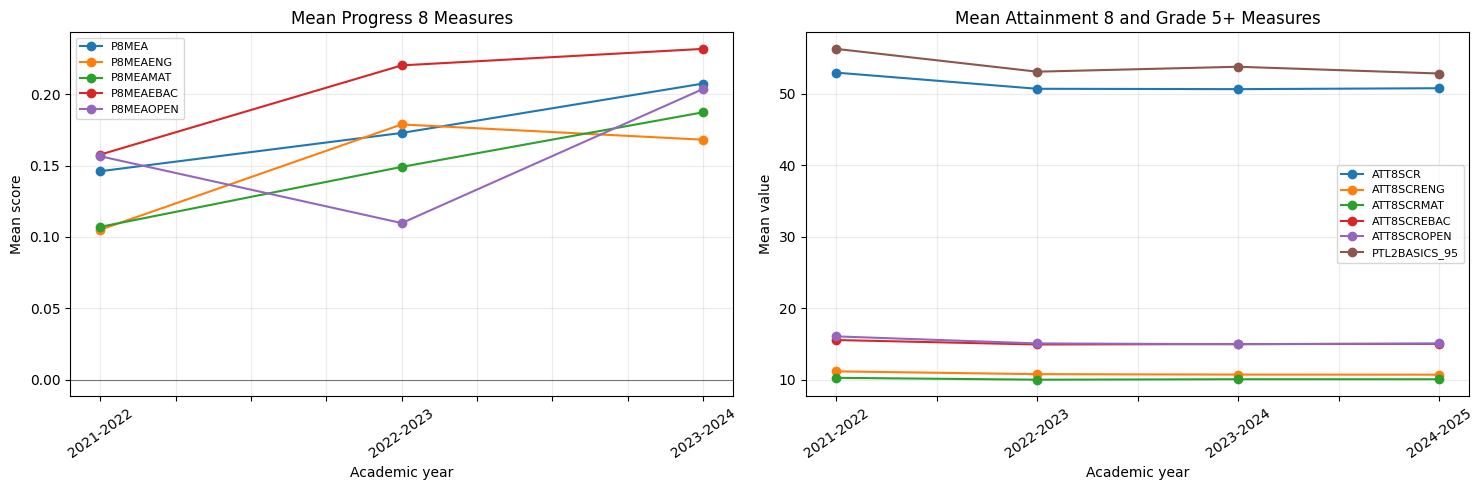

In [63]:
progress8_columns = ["P8MEA", "P8MEAENG", "P8MEAMAT", "P8MEAEBAC", "P8MEAOPEN"]
attainment8_columns = ["ATT8SCR", "ATT8SCRENG", "ATT8SCRMAT", "ATT8SCREBAC", "ATT8SCROPEN"]

progress8_trends = panel.groupby("academic_year")[progress8_columns].mean()
attainment_trends = panel.groupby("academic_year")[attainment8_columns + ["PTL2BASICS_95"]].mean()

display(progress8_trends.round(2))
display(attainment_trends.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
progress8_trends.plot(marker="o", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[0].set_title("Mean Progress 8 Measures")
axes[0].set_xlabel("Academic year")
axes[0].set_ylabel("Mean score")
axes[0].tick_params(axis="x", rotation=35)

attainment_trends.plot(marker="o", ax=axes[1])
axes[1].set_title("Mean Attainment 8 and Grade 5+ Measures")
axes[1].set_xlabel("Academic year")
axes[1].set_ylabel("Mean value")
axes[1].tick_params(axis="x", rotation=35)

for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)

plt.tight_layout()

* Average Progress 8 scores across Hertfordshire secondary schools were consistently above the national benchmark between 2021/22 and 2023/24, suggesting pupils made modestly stronger progress than comparable pupils nationally
* Above-average Progress 8 outcomes may partly reflect local demographic and admissions dynamics, including selective and partially selective intake patterns that are not fully captured by published admissions-policy classifications
* Published admissions-policy classifications did not consistently identify all academically selective or partially selective schools. Additional contextual interpretation was therefore required when analysing selectivity-related patterns

## Context Relationships

The following charts use only `State-funded secondary` schools. They are descriptive associations and do not estimate causal effects.

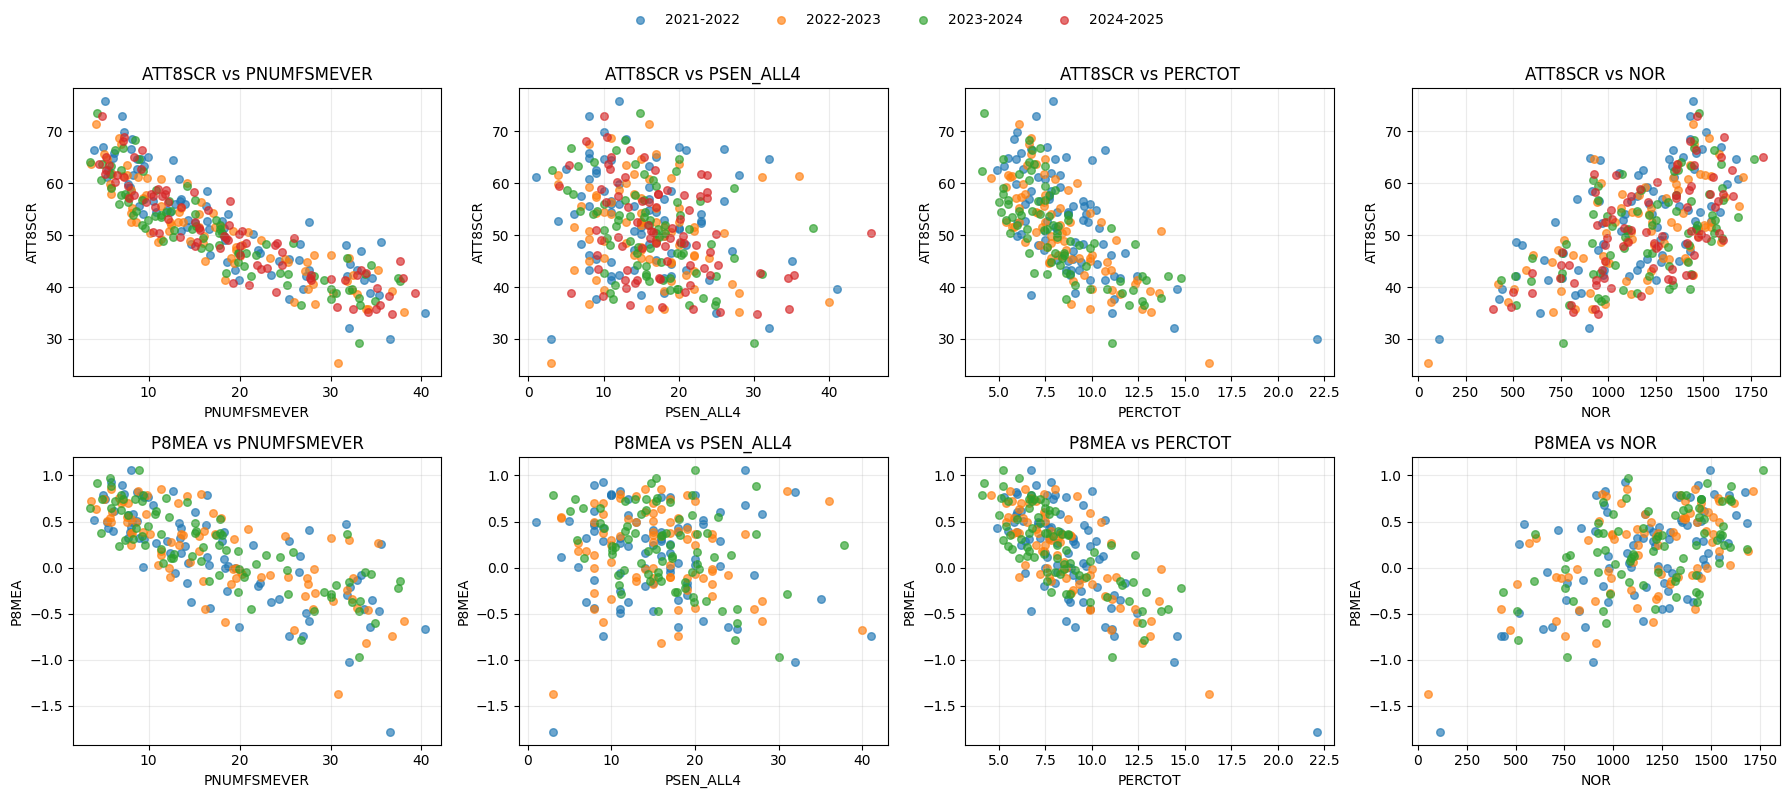

In [72]:
state_funded_panel = panel.copy()

def scatter_by_year(x: str, y: str, ax: plt.Axes) -> None:
    valid = state_funded_panel.dropna(subset=[x, y])
    for year, group in valid.groupby("academic_year"):
        ax.scatter(group[x], group[y], label=year, alpha=0.65, s=30)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} vs {x}")
    ax.grid(alpha=0.25)


scatter_pairs = [
    ("PNUMFSMEVER", "ATT8SCR"),
    ("PSEN_ALL4", "ATT8SCR"),
    ("PERCTOT", "ATT8SCR"),
    ("NOR", "ATT8SCR"),
    ("PNUMFSMEVER", "P8MEA"),
    ("PSEN_ALL4", "P8MEA"),
    ("PERCTOT", "P8MEA"),
    ("NOR", "P8MEA"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for axis, (x, y) in zip(axes.ravel(), scatter_pairs):
    scatter_by_year(x, y, axis)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(YEARS), frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.94])

* Across 2021/22–2024/25, secondary school attainment and progress outcomes in Hertfordshire show strong relationships with deprivation, attendance, and school size, while SEND prevalence shows a weaker and more dispersed association.
* Socioeconomic disadvantage remains strongly associated with lower GCSE attainment outcomes and continue to influence pupil progress even after accounting for prior attainment.
* Overall attendence is also strongly associated with Attainment 8 outcomes and  Progress 8 scores.
* Larger schools tend to have higher Attainment 8 scores and higher Progress 8 scores. However, this relationship likely reflects confounding factors, school selectivity, demographic composition, and affluent catchment effects, rather than a direct effect of school size itself.

,ATT8SCR,P8MEA,PNUMFSMEVER,PERCTOT,PPERSABS10,PSEN_ALL4,NOR,PNORG
ATT8SCR,1.00,0.88,-0.88,-0.68,-0.59,-0.29,0.59,0.11
P8MEA,0.88,1.00,-0.75,-0.75,-0.68,-0.18,0.53,0.15
PNUMFSMEVER,-0.88,-0.75,1.00,0.65,0.57,0.28,-0.57,-0.03
PERCTOT,-0.68,-0.75,0.65,1.00,0.95,0.21,-0.49,0.06
PPERSABS10,-0.59,-0.68,0.57,0.95,1.00,0.17,-0.46,0.11
PSEN_ALL4,-0.29,-0.18,0.28,0.21,0.17,1.00,-0.15,-0.02
NOR,0.59,0.53,-0.57,-0.49,-0.46,-0.15,1.00,-0.02
PNORG,0.11,0.15,-0.03,0.06,0.11,-0.02,-0.02,1.00


,correlation_with_ATT8SCR,correlation_with_P8MEA
PNUMFSMEVER,-0.88,-0.75
PERCTOT,-0.68,-0.75
NOR,0.59,0.53
PPERSABS10,-0.59,-0.68
PSEN_ALL4,-0.29,-0.18
PNORG,0.11,0.15


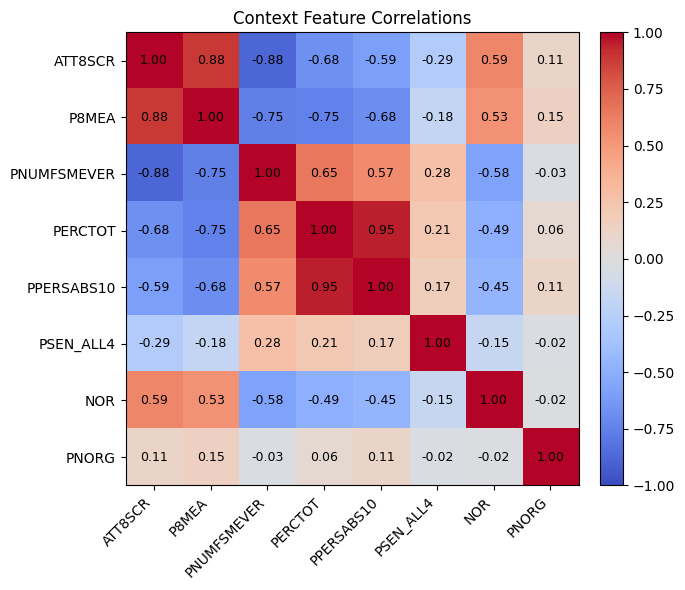

In [73]:
TARGETS = ["ATT8SCR", "P8MEA"]
NUMERIC_CONTEXT_COLUMNS = ["PNUMFSMEVER", "PERCTOT", "PPERSABS10", "PSEN_ALL4", "NOR", "PNORG"]

NUMERIC_FEATURES = panel[TARGETS + NUMERIC_CONTEXT_COLUMNS].apply(pd.to_numeric, errors="coerce")
feature_correlations = NUMERIC_FEATURES.corr()

fig, axis = plt.subplots(figsize=(7, 6))
heatmap = axis.imshow(feature_correlations, cmap="coolwarm", vmin=-1, vmax=1)
axis.set_xticks(range(len(feature_correlations.columns)))
axis.set_xticklabels(feature_correlations.columns, rotation=45, ha="right")
axis.set_yticks(range(len(feature_correlations.index)))
axis.set_yticklabels(feature_correlations.index)

for row in range(len(feature_correlations.index)):
    for col in range(len(feature_correlations.columns)):
        value = feature_correlations.iloc[row, col]
        axis.text(col, row, f"{value:.2f}", ha="center", va="center", color="black", fontsize=9)

axis.set_title("Context Feature Correlations")
fig.colorbar(heatmap, ax=axis, fraction=0.046, pad=0.04)
plt.tight_layout()

display(feature_correlations.round(3))
display(
    feature_correlations.loc[NUMERIC_CONTEXT_COLUMNS, TARGETS]
    .sort_values("ATT8SCR", key=lambda values: values.abs(), ascending=False)
    .round(3)
    .rename(columns={target: f"correlation_with_{target}" for target in TARGETS})
)

* `PNUMFSMEVER`, `PERCTOT`, `PPERSABS10`, and `NOR` is strongly related to `ATT8SCR` and `P8MEA`, however, `PERCTOT` and `PPERSABS10` are strongly related.
* The correlation coefficients shows that `PSEN_ALL4` has a moderate relationship with attaiment while `PNORG` has a weak relationship with attainment

## Multiple Regression: Predicting Attainment and Progress

This section predicts `ATT8SCR` and `P8MEA` using selected context variables for state-funded secondary schools. It is descriptive and predictive, not causal.

`PPERSABS10` is omitted because it is strongly related to `PERCTOT`, while `PNORG` is omitted because the correlation check shows a weak relationship with attainment. The numeric regression features are therefore `PNUMFSMEVER`, `PERCTOT`, `PSEN_ALL4`, and `NOR`. `PERCTOT` and `P8MEA` are not available for `2024-2025`, so the models use years with the required target and attendance data only.

,ATT8SCR,P8MEA
academic_year,,
2021-2022,79,79
2022-2023,79,79
2023-2024,77,77


,target,observations,features,df_model,df_resid,r2,adjusted_r2,f_pvalue,rmse,mae
0,ATT8SCR,235,10,10.00,224.00,0.82,0.81,0.00,3.93,3.12
1,P8MEA,235,10,10.00,224.00,0.72,0.71,0.00,0.25,0.20


,target,feature,coefficient,std_error,t_stat,p_value,ci_lower,ci_upper
0,ATT8SCR,Intercept,51.72,2.68,19.30,0.00,46.44,57.00
1,ATT8SCR,PNUMFSMEVER,-6.06,0.41,-14.83,0.00,-6.87,-5.26
2,ATT8SCR,EGENDER_GIRLS,4.67,1.37,3.40,0.00,1.97,7.37
3,ATT8SCR,academic_year_2023-2024,-2.77,0.65,-4.26,0.00,-4.05,-1.49
4,ATT8SCR,academic_year_2022-2023,-2.47,0.64,-3.85,0.00,-3.73,-1.21
5,ATT8SCR,PERCTOT,-1.87,0.37,-5.00,0.00,-2.61,-1.14
6,ATT8SCR,ADMPOL_NSE,1.75,2.42,0.72,0.47,-3.02,6.53
7,ATT8SCR,ADMPOL_NR,1.01,2.61,0.39,0.70,-4.14,6.16
8,ATT8SCR,EGENDER_MIXED,-0.79,1.13,-0.70,0.48,-3.02,1.43
9,ATT8SCR,NOR,0.45,0.36,1.25,0.21,-0.26,1.17


,target,academic_year,URN,SCHNAME,actual,predicted,residual
14,ATT8SCR,2021-2022,136554,Dame Alice Owen's School,75.80,61.29,14.51
172,ATT8SCR,2023-2024,136554,Dame Alice Owen's School,73.50,62.02,11.48
203,ATT8SCR,2023-2024,136899,Parmiter's School,68.30,57.45,10.85
192,ATT8SCR,2023-2024,146440,Laureate Academy,41.70,31.15,10.55
93,ATT8SCR,2022-2023,136554,Dame Alice Owen's School,71.40,60.88,10.52
153,ATT8SCR,2022-2023,136276,Watford Grammar School for Boys,68.80,59.71,9.09
16,ATT8SCR,2021-2022,117504,Fearnhill School,48.60,39.86,8.74
158,ATT8SCR,2023-2024,145430,The Adeyfield Academy,29.20,37.57,-8.37
155,ATT8SCR,2022-2023,141004,The Watford UTC,25.30,33.36,-8.06
146,ATT8SCR,2022-2023,140294,Simon Balle All-Through School,48.60,56.56,-7.96


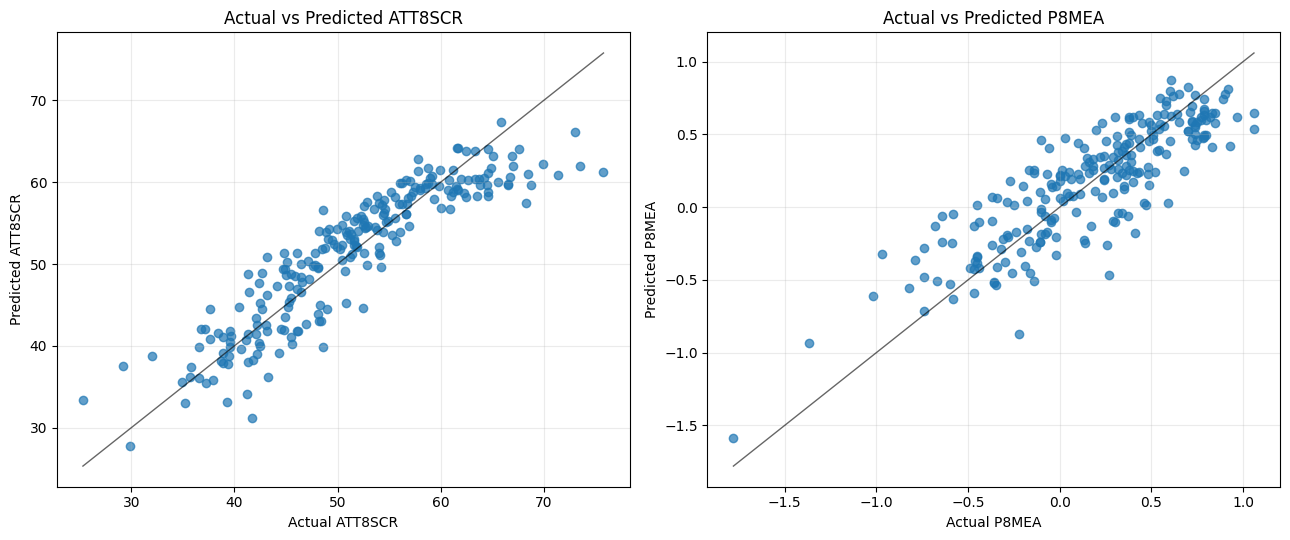

In [71]:
REGRESSION_TARGETS = ["ATT8SCR", "P8MEA"]
REGRESSION_NUMERIC_FEATURES = ["PNUMFSMEVER", "PERCTOT", "PSEN_ALL4", "NOR"]
REGRESSION_CATEGORICAL_FEATURES = ["academic_year", "EGENDER", "ADMPOL"]

regression_row_counts = []
regression_summaries = []
coefficient_tables = []
prediction_tables = []

for target in REGRESSION_TARGETS:
    regression_columns = [target] + REGRESSION_NUMERIC_FEATURES + REGRESSION_CATEGORICAL_FEATURES + ["URN", "SCHNAME"]
    regression_data = panel[regression_columns].copy()
    regression_data[REGRESSION_CATEGORICAL_FEATURES] = regression_data[REGRESSION_CATEGORICAL_FEATURES].fillna("Missing")
    regression_data = regression_data.dropna(subset=[target] + REGRESSION_NUMERIC_FEATURES).copy()

    X_numeric_raw = regression_data[REGRESSION_NUMERIC_FEATURES].astype(float)
    feature_means = X_numeric_raw.mean()
    feature_stds = X_numeric_raw.std(ddof=0).replace(0, 1)
    X_numeric = (X_numeric_raw - feature_means) / feature_stds
    X_categorical = pd.get_dummies(regression_data[REGRESSION_CATEGORICAL_FEATURES], drop_first=True, dtype=float)
    X = pd.concat([X_numeric, X_categorical], axis=1)
    X = sm.add_constant(X, has_constant="add").rename(columns={"const": "Intercept"})
    y = regression_data[target].astype(float)

    model = sm.OLS(y, X).fit()
    predicted = model.predict(X)
    errors = y - predicted

    n_obs = len(y)
    n_features = X.shape[1] - 1
    rmse = float(np.sqrt(np.mean(errors**2)))
    mae = float(np.mean(np.abs(errors)))
    confidence_intervals = model.conf_int().rename(columns={0: "ci_lower", 1: "ci_upper"})

    regression_row_counts.append(regression_data.groupby("academic_year").size().rename(target))
    regression_summaries.append(
        {
            "target": target,
            "observations": n_obs,
            "features": n_features,
            "df_model": model.df_model,
            "df_resid": model.df_resid,
            "r2": model.rsquared,
            "adjusted_r2": model.rsquared_adj,
            "f_pvalue": model.f_pvalue,
            "rmse": rmse,
            "mae": mae,
        }
    )

    coefficient_tables.append(
        pd.DataFrame(
            {
                "target": target,
                "feature": model.params.index,
                "coefficient": model.params.values,
                "std_error": model.bse.values,
                "t_stat": model.tvalues.values,
                "p_value": model.pvalues.values,
            }
        )
        .merge(confidence_intervals.reset_index().rename(columns={"index": "feature"}), on="feature", how="left")
        .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
        .sort_values("abs_coefficient", ascending=False)
        .drop(columns="abs_coefficient")
    )

    prediction_table = regression_data[["academic_year", "URN", "SCHNAME", target]].rename(columns={target: "actual"})
    prediction_table.insert(0, "target", target)
    prediction_table["predicted"] = predicted
    prediction_table["residual"] = prediction_table["actual"] - prediction_table["predicted"]
    prediction_tables.append(prediction_table)

regression_row_counts = pd.concat(regression_row_counts, axis=1).fillna(0).astype(int)
regression_summary = pd.DataFrame(regression_summaries)
coefficient_table = pd.concat(coefficient_tables, ignore_index=True)
prediction_results = pd.concat(prediction_tables, ignore_index=True)

display(regression_row_counts)
display(regression_summary.round(3))
display(coefficient_table.round(3))
display(
    prediction_results.assign(abs_residual=lambda frame: frame["residual"].abs())
    .sort_values(["target", "abs_residual"], ascending=[True, False])
    .groupby("target")
    .head(10)
    .drop(columns="abs_residual")
    .round(2)
)

fig, axes = plt.subplots(1, len(REGRESSION_TARGETS), figsize=(6.5 * len(REGRESSION_TARGETS), 5.5))
for axis, target in zip(np.atleast_1d(axes), REGRESSION_TARGETS):
    target_predictions = prediction_results[prediction_results["target"].eq(target)]
    axis.scatter(target_predictions["actual"], target_predictions["predicted"], alpha=0.7)
    line_min = min(target_predictions["actual"].min(), target_predictions["predicted"].min())
    line_max = max(target_predictions["actual"].max(), target_predictions["predicted"].max())
    axis.plot([line_min, line_max], [line_min, line_max], color="black", linewidth=1, alpha=0.6)
    axis.set_title(f"Actual vs Predicted {target}")
    axis.set_xlabel(f"Actual {target}")
    axis.set_ylabel(f"Predicted {target}")
    axis.grid(alpha=0.25)
plt.tight_layout()

### Regression Results Summary

The regression models use 235 school-year observations because `2024-2025` rows are dropped where `PERCTOT` and `P8MEA` are unavailable. The numeric predictors are standardised, so coefficient sizes are comparable within each target model.

- The `ATT8SCR` model explains a large share of variation (`R2` about **0.82**, adjusted `R2` about **0.81**). `PNUMFSMEVER` is the strongest negative predictor, followed by `PERCTOT`. `NOR` has a small positive coefficient and `PSEN_ALL4` is close to zero after the other context variables and categorical controls are included.
- The `P8MEA` model also has strong descriptive fit (`R2` about **0.72**, adjusted `R2` about **0.71**). `PERCTOT` and `PNUMFSMEVER` are the main negative predictors, while `PSEN_ALL4` and `NOR` have very small coefficients.
- Overall, deprivation and attendance are the clearest context signals for both attainment and progress. The models should still be treated as descriptive because the predictors are correlated and school composition, admissions context, and local catchment effects are not fully separable.

## Grouped Summaries

In [67]:
def grouped_summary(group_col: str) -> pd.DataFrame:
    return (
        panel.groupby(["academic_year", group_col], dropna=False)
        .agg(
            schools=("URN", "count"),
            mean_p8=("P8MEA", "mean"),
            mean_att8=("ATT8SCR", "mean"),
            mean_grade5=("PTL2BASICS_95", "mean"),
            mean_fsm=("PNUMFSMEVER", "mean"),
            mean_persistent_absence=("PPERSABS10", "mean"),
            mean_send=("PSEN_ALL4", "mean"),
            mean_nor=("NOR", "mean"),
            mean_norg=("NORG", "mean"),
            mean_norb=("NORB", "mean"),
            mean_pnorg=("PNORG", "mean"),
            mean_pnorb=("PNORB", "mean"),
        )
        .reset_index()
        .sort_values(["academic_year", "schools"], ascending=[True, False])
    )


for group_column in ["SCHOOLTYPE", "ADMPOL", "EGENDER"]:
    print(f"\n{group_column}")
    display(grouped_summary(group_column).round(2))


SCHOOLTYPE


,academic_year,SCHOOLTYPE,schools,mean_p8,mean_att8,mean_grade5,mean_fsm,mean_persistent_absence,mean_send,mean_nor,mean_norg,mean_norb,mean_pnorg,mean_pnorb
0,2021-2022,State-funded secondary,80,0.15,52.93,56.25,17.58,26.46,15.54,1137.58,568.09,569.49,49.91,50.09
1,2022-2023,State-funded secondary,81,0.17,50.67,53.06,17.50,24.59,15.87,1147.11,572.15,574.93,49.93,50.07
2,2023-2024,State-funded secondary,79,0.21,50.62,53.75,17.46,23.37,16.39,1179.49,588.30,591.19,50.04,49.96
3,2024-2025,State-funded secondary,80,<NA>,50.75,52.81,18.76,<NA>,17.59,1180.62,590.36,590.26,50.19,49.81



ADMPOL


,academic_year,ADMPOL,schools,mean_p8,mean_att8,mean_grade5,mean_fsm,mean_persistent_absence,mean_send,mean_nor,mean_norg,mean_norb,mean_pnorg,mean_pnorb
1,2021-2022,NSE,73,0.19,53.79,57.88,16.69,26.05,15.68,1182.26,592.48,589.78,50.31,49.69
0,2021-2022,NR,6,-0.51,41.88,36.40,26.89,31.35,13.20,673.17,313.00,360.17,45.32,54.68
2,2021-2022,<NA>,1,-0.05,45.20,37.00,26.55,27.30,17.00,662.00,318.00,344.00,48.04,51.96
4,2022-2023,NSE,74,0.22,51.62,54.75,16.65,24.06,16.10,1187.24,593.80,593.41,50.31,49.69
3,2022-2023,NR,6,-0.50,37.96,30.60,26.77,31.22,12.40,725.50,342.17,383.33,45.28,54.72
5,2022-2023,<NA>,1,-0.10,44.90,42.00,25.30,24.40,17.00,707.00,350.00,357.00,49.50,50.50
7,2023-2024,NSE,72,0.23,51.20,54.93,16.77,22.71,16.37,1206.76,604.17,602.60,50.32,49.68
6,2023-2024,NR,6,-0.06,43.92,40.16,24.53,31.57,15.44,922.50,435.50,487.00,46.95,53.05
8,2023-2024,<NA>,1,0.11,42.70,38.40,24.40,22.10,22.30,758.00,363.00,395.00,47.90,52.10
10,2024-2025,NSE,73,<NA>,51.37,54.10,18.08,<NA>,17.63,1208.92,606.23,602.68,50.42,49.58



EGENDER


,academic_year,EGENDER,schools,mean_p8,mean_att8,mean_grade5,mean_fsm,mean_persistent_absence,mean_send,mean_nor,mean_norg,mean_norb,mean_pnorg,mean_pnorb
2,2021-2022,MIXED,68,0.06,51.14,52.84,19.00,27.04,15.93,1119.09,541.56,577.53,48.40,51.60
1,2021-2022,GIRLS,7,0.75,64.76,75.71,9.96,25.13,13.14,1233.86,1205.43,28.43,97.96,2.04
0,2021-2022,BOYS,5,0.40,60.32,74.80,8.91,20.48,13.80,1254.20,36.60,1217.60,3.11,96.89
5,2022-2023,MIXED,69,0.10,49.02,49.96,18.87,25.14,16.42,1127.55,544.74,582.77,48.46,51.53
4,2022-2023,GIRLS,7,0.69,60.43,69.43,10.29,24.93,11.86,1255.43,1223.29,32.14,97.70,2.30
3,2022-2023,BOYS,5,0.47,59.12,71.80,8.74,16.56,14.20,1265.40,38.80,1226.60,3.26,96.74
8,2023-2024,MIXED,67,0.15,49.13,50.93,18.84,24.04,17.12,1165.03,562.81,602.22,48.51,51.49
7,2023-2024,GIRLS,7,0.61,59.93,69.59,10.33,21.93,12.03,1250.14,1221.43,28.71,97.84,2.16
6,2023-2024,BOYS,5,0.45,56.90,68.26,8.84,16.50,13.02,1274.40,43.60,1230.80,3.58,96.42
11,2024-2025,MIXED,68,<NA>,49.20,50.01,20.24,<NA>,18.17,1166.60,565.93,600.68,48.68,51.32


## Ranked School Tables

In [68]:
ranking_columns = [
    "academic_year",
    "URN",
    "SCHNAME",
    "SCHOOLTYPE",
    "ADMPOL",
    "EGENDER",
    "P8MEA",
    "ATT8SCR",
    "PTL2BASICS_95",
    "PNUMFSMEVER",
    "PPERSABS10",
    "PSEN_ALL4",
    "NOR",
    "NORG",
    "NORB",
    "PNORG",
    "PNORB",
]

high_deprivation = (
    panel.dropna(subset=["PNUMFSMEVER"])
    .sort_values(["academic_year", "PNUMFSMEVER", "ATT8SCR"], ascending=[True, False, False])
    .groupby("academic_year")
    .head(10)[ranking_columns]
)

highest_attainment = (
    panel.dropna(subset=["ATT8SCR"])
    .sort_values(["academic_year", "ATT8SCR"], ascending=[True, False])
    .groupby("academic_year")
    .head(10)[ranking_columns]
)
print ('High deprivation schools:')
display(high_deprivation.round(2))
print ('High attaiment schools:')
display(highest_attainment.round(2))

High deprivation schools:


,academic_year,URN,SCHNAME,SCHOOLTYPE,ADMPOL,EGENDER,P8MEA,ATT8SCR,PTL2BASICS_95,PNUMFSMEVER,PPERSABS10,PSEN_ALL4,NOR,NORG,NORB,PNORG,PNORB
0,2021-2022,145430,The Adeyfield Academy,State-funded secondary,NSE,MIXED,-0.67,34.90,21.00,40.34,36.60,25.00,642,305,337,47.51,52.49
77,2021-2022,141004,The Watford UTC,State-funded secondary,NR,MIXED,-1.78,29.90,24.00,36.59,69.10,3.00,112,47,65,41.96,58.04
16,2021-2022,117504,Fearnhill School,State-funded secondary,NSE,MIXED,0.26,48.60,52.00,35.59,24.50,17.00,516,252,264,48.84,51.16
46,2021-2022,147535,Onslow St Audreys School,State-funded secondary,NR,MIXED,-0.47,38.40,25.00,35.28,17.80,15.00,824,332,492,40.29,59.71
36,2021-2022,146440,Laureate Academy,State-funded secondary,NR,MIXED,-0.35,41.80,35.00,34.60,37.00,18.00,756,371,385,49.07,50.93
2,2021-2022,117552,The Astley Cooper School,State-funded secondary,NSE,MIXED,-0.64,38.90,34.00,34.37,30.70,18.00,857,429,428,50.06,49.94
25,2021-2022,138747,Hertswood Academy,State-funded secondary,NSE,MIXED,-0.45,41.30,36.00,33.68,31.30,11.00,1250,597,653,47.76,52.24
41,2021-2022,117534,Marriotts School,State-funded secondary,NSE,MIXED,-0.08,46.90,37.00,33.36,26.50,27.00,1432,694,738,48.46,51.54
22,2021-2022,142051,Haileybury Turnford,State-funded secondary,NSE,MIXED,-0.13,43.20,42.00,32.95,32.10,8.00,843,401,442,47.57,52.43
63,2021-2022,138360,St Mary's Church of England High School (VA),State-funded secondary,NSE,MIXED,-0.21,44.50,34.00,32.18,37.10,19.00,1167,580,587,49.70,50.30


High attaiment schools:


,academic_year,URN,SCHNAME,SCHOOLTYPE,ADMPOL,EGENDER,P8MEA,ATT8SCR,PTL2BASICS_95,PNUMFSMEVER,PPERSABS10,PSEN_ALL4,NOR,NORG,NORB,PNORG,PNORB
14,2021-2022,136554,Dame Alice Owen's School,State-funded secondary,NSE,MIXED,0.74,75.80,90.00,5.20,26.00,12.00,1447,734,713,50.73,49.27
76,2021-2022,136289,Watford Grammar School for Girls,State-funded secondary,NSE,GIRLS,0.90,73.00,88.00,7.11,20.20,8.00,1432,1432,0,100.00,0.00
75,2021-2022,136276,Watford Grammar School for Boys,State-funded secondary,NSE,BOYS,0.80,69.90,89.00,7.33,14.40,10.00,1516,0,1516,0.00,100.00
47,2021-2022,136899,Parmiter's School,State-funded secondary,NSE,MIXED,0.50,68.50,83.00,8.15,17.70,13.00,1429,676,753,47.31,52.69
58,2021-2022,136901,St Clement Danes School,State-funded secondary,NSE,MIXED,0.79,67.00,82.00,4.92,27.30,20.00,1594,795,799,49.87,50.13
5,2021-2022,138286,Beaumont School,State-funded secondary,NSE,MIXED,1.06,66.70,82.00,8.06,14.70,26.00,1496,706,790,47.19,52.81
59,2021-2022,138356,St George's School,State-funded secondary,NSE,MIXED,0.52,66.50,84.00,4.02,38.40,21.00,1344,707,637,52.60,47.40
24,2021-2022,140786,The Hertfordshire & Essex High School and Scie...,State-funded secondary,NSE,GIRLS,0.61,65.90,81.00,6.20,14.10,8.00,1463,1296,167,88.59,11.41
57,2021-2022,137339,St Albans Girls' School,State-funded secondary,NSE,GIRLS,0.77,65.10,72.00,9.92,25.30,17.00,1392,1391,1,99.93,0.07
29,2021-2022,136482,Hockerill Anglo-European College,State-funded secondary,NSE,MIXED,0.40,64.90,77.00,6.07,10.00,8.00,904,444,460,49.12,50.88


### Latest-Year Ranked Schools Map

The school information files provide postcodes rather than coordinates. This cell geocodes the latest-year ranked-school postcodes through postcodes.io, caches the latitude/longitude lookup in `data/postcode_coordinates_cache.csv`, and displays the ranked schools on an interactive Folium map.

In [69]:
import html

import folium
import requests


def normalise_postcode(series: pd.Series) -> pd.Series:
    return series.astype("string").str.upper().str.replace(r"\s+", "", regex=True)


def load_postcode_cache(cache_path: Path) -> pd.DataFrame:
    if cache_path.exists():
        return pd.read_csv(cache_path, dtype={"postcode_key": "string"})
    return pd.DataFrame(columns=["postcode_key", "latitude", "longitude"])


def geocode_postcodes(postcodes: pd.Series, cache_path: Path) -> pd.DataFrame:
    cache = load_postcode_cache(cache_path)
    cache["postcode_key"] = cache["postcode_key"].astype("string")
    postcode_keys = pd.Series(postcodes.dropna().unique(), dtype="string")
    missing_postcodes = postcode_keys[~postcode_keys.isin(cache["postcode_key"])]

    if not missing_postcodes.empty:
        try:
            response = requests.post(
                "https://api.postcodes.io/postcodes",
                json={"postcodes": missing_postcodes.tolist()},
                timeout=20,
            )
            response.raise_for_status()
            new_rows = []
            for item in response.json().get("result", []):
                result = item.get("result")
                if result:
                    new_rows.append(
                        {
                            "postcode_key": normalise_postcode(pd.Series([item.get("query")])).iloc[0],
                            "latitude": result.get("latitude"),
                            "longitude": result.get("longitude"),
                        }
                    )
            if new_rows:
                cache = pd.concat([cache, pd.DataFrame(new_rows)], ignore_index=True)
                cache = cache.drop_duplicates(subset="postcode_key", keep="last")
                cache.to_csv(cache_path, index=False)
        except requests.RequestException as exc:
            print(f"Postcode geocoding failed: {exc}")

    return cache


latest_year = YEARS[-1]
school_info = pd.read_csv(
    DATA_DIR / latest_year / "919_school_information.csv",
    usecols=["URN", "POSTCODE", "TOWN"],
    dtype="string",
)
school_info["URN"] = normalise_urn(school_info["URN"])
school_info["postcode_key"] = normalise_postcode(school_info["POSTCODE"])
school_info = school_info.drop_duplicates(subset="URN")

latest_high_deprivation = high_deprivation[high_deprivation["academic_year"].eq(latest_year)].copy()
latest_high_deprivation["rank_group"] = "High deprivation"
latest_high_deprivation["rank"] = range(1, len(latest_high_deprivation) + 1)

latest_highest_attainment = highest_attainment[highest_attainment["academic_year"].eq(latest_year)].copy()
latest_highest_attainment["rank_group"] = "Highest attainment"
latest_highest_attainment["rank"] = range(1, len(latest_highest_attainment) + 1)

latest_ranked_schools = pd.concat([latest_high_deprivation, latest_highest_attainment], ignore_index=True)
latest_ranked_schools = latest_ranked_schools.merge(
    school_info[["URN", "POSTCODE", "TOWN", "postcode_key"]],
    on="URN",
    how="left",
    validate="many_to_one",
)

postcode_cache_path = DATA_DIR / "postcode_coordinates_cache.csv"
postcode_coordinates = geocode_postcodes(latest_ranked_schools["postcode_key"], postcode_cache_path)
latest_ranked_map_data = latest_ranked_schools.merge(postcode_coordinates, on="postcode_key", how="left")
latest_ranked_map_data = latest_ranked_map_data.dropna(subset=["latitude", "longitude"]).copy()

display(
    latest_ranked_map_data[
        ["rank_group", "rank", "SCHNAME", "POSTCODE", "TOWN", "ATT8SCR", "PNUMFSMEVER", "latitude", "longitude"]
    ].round(4)
)

if latest_ranked_map_data.empty:
    print("No mapped schools available. Check postcodes and the geocoding cache.")
else:
    school_map = folium.Map(
        location=[latest_ranked_map_data["latitude"].mean(), latest_ranked_map_data["longitude"].mean()],
        zoom_start=10,
        tiles="OpenStreetMap",
    )
    marker_colours = {"High deprivation": "red", "Highest attainment": "green"}

    for rank_group, group in latest_ranked_map_data.groupby("rank_group"):
        feature_group = folium.FeatureGroup(name=rank_group)
        for _, row in group.iterrows():
            popup_html = f"""
            <b>{html.escape(str(row['SCHNAME']))}</b><br>
            {html.escape(str(rank_group))} rank: {int(row['rank'])}<br>
            Postcode: {html.escape(str(row['POSTCODE']))}<br>
            ATT8SCR: {row['ATT8SCR']:.2f}<br>
            PNUMFSMEVER: {row['PNUMFSMEVER']:.2f}
            """
            folium.CircleMarker(
                location=[row["latitude"], row["longitude"]],
                radius=7,
                color=marker_colours.get(rank_group, "blue"),
                fill=True,
                fill_opacity=0.75,
                popup=folium.Popup(popup_html, max_width=320),
                tooltip=f"{rank_group}: {row['SCHNAME']}",
            ).add_to(feature_group)
        feature_group.add_to(school_map)

    folium.LayerControl(collapsed=False).add_to(school_map)
    display(school_map)

,rank_group,rank,SCHNAME,POSTCODE,TOWN,ATT8SCR,PNUMFSMEVER,latitude,longitude
0,High deprivation,1,Fearnhill School,SG6 4BA,Letchworth,38.90,39.30,51.98,-0.25
1,High deprivation,2,Laureate Academy,HP1 3DW,Hemel Hempstead,41.70,37.95,51.76,-0.48
2,High deprivation,3,St Mary's Church of England High School (VA),EN7 5FB,Waltham Cross,45.00,37.61,51.70,-0.05
3,High deprivation,4,The Astley Cooper School,HP2 7HL,Hemel Hempstead,34.70,36.77,51.78,-0.45
4,High deprivation,5,Hertswood Academy,WD6 5LG,Borehamwood,38.30,36.40,51.67,-0.27
5,High deprivation,6,Onslow St Audrey's School,AL10 8AB,Hatfield,36.60,35.48,51.76,-0.22
6,High deprivation,7,Future Academies Watford,WD25 7HW,Watford,39.80,35.08,51.70,-0.39
7,High deprivation,8,The Sele School,SG14 2DG,Hertford,35.70,34.99,51.80,-0.10
8,High deprivation,9,The Adeyfield Academy,HP2 4DE,Hemel Hempstead,35.10,34.16,51.75,-0.45
9,High deprivation,10,Goffs - Churchgate Academy,EN8 9LY,Waltham Cross,42.60,33.89,51.70,-0.05


## Summary

This analysis covers **state-funded secondary schools only**. The regression models exclude `2024-2025` because attendance (`PERCTOT`) and Progress 8 (`P8MEA`) are not populated for that year.

**Regression results**

- The `ATT8SCR` model has strong descriptive fit (`R2` about **0.82**). `PNUMFSMEVER` is the largest negative predictor, followed by `PERCTOT`; `NOR` is small and positive, and `PSEN_ALL4` is close to zero after controls.
- The `P8MEA` model also fits well (`R2` about **0.72**). `PERCTOT` and `PNUMFSMEVER` are the clearest negative predictors, while `NOR` and `PSEN_ALL4` add little once the other variables are included.
- The models are descriptive, not causal: deprivation, attendance, school size, admissions context, and local catchment effects are correlated.

**Policy implications**

- Prioritise schools with high `PNUMFSMEVER`, then use attendance as the main operational lens for follow-up.
- Treat SEND and school-size patterns cautiously in policy decisions because their regression signals are weak after deprivation and attendance are included.
- Keep `2024-2025` Progress 8 and attendance claims out of trend conclusions unless those fields become available.

**Ranked tables**

- The ranked tables identify the highest-deprivation schools and the highest-attainment schools by year. They are best used as a shortlist for targeted review, not as standalone evidence of performance quality.
- The latest-year map helps show whether ranked schools cluster geographically, which can support place-based follow-up alongside the regression evidence.
